In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


 # Question 1: Tackling Mode Collapse in Generative Adversarial Networks

In [1]:
!pip install torch torchvision gradio tqdm

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os
from PIL import Image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

IMAGE_SIZE = 64
BATCH_SIZE = 64
Z_DIM = 100
CHANNELS_IMG = 3
FEATURES_GEN = 64
FEATURES_DISC = 64

EPOCHS_DCGAN = 40
EPOCHS_WGAN = 35

LR = 0.0002
BETAS = (0.5,0.999)

CRITIC_ITERATIONS = 5
LAMBDA_GP = 10

cuda


In [4]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

dataset = torchvision.datasets.ImageFolder(
    root="/kaggle/input/datasets/soumikrakshit/anime-faces/data",
    transform=transform
)

loader = DataLoader(dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=2)

Text(0.5, 1.0, 'Training Images')

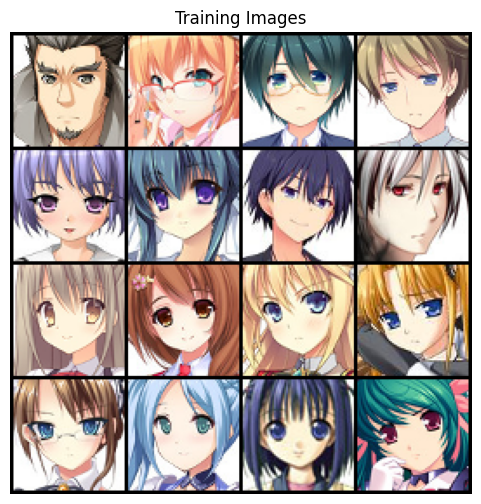

In [5]:
dataiter = iter(loader)
images,_ = next(dataiter)

grid = make_grid(images[:16],nrow=4,normalize=True)

plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid,(1,2,0)))
plt.axis("off")
plt.title("Training Images")

In [6]:
class Generator(nn.Module):
    def __init__(self,z_dim,channels_img,features_g):
        super().__init__()

        self.net = nn.Sequential(

            nn.ConvTranspose2d(z_dim,features_g*16,4,1,0,bias=False),
            nn.BatchNorm2d(features_g*16),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g*16,features_g*8,4,2,1,bias=False),
            nn.BatchNorm2d(features_g*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g*8,features_g*4,4,2,1,bias=False),
            nn.BatchNorm2d(features_g*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g*4,features_g*2,4,2,1,bias=False),
            nn.BatchNorm2d(features_g*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g*2,channels_img,4,2,1,bias=False),
            nn.Tanh()
        )

    def forward(self,x):
        return self.net(x)

In [7]:
class Discriminator(nn.Module):
    def __init__(self,channels_img,features_d):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(channels_img,features_d,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d,features_d*2,4,2,1),
            nn.BatchNorm2d(features_d*2),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d*2,features_d*4,4,2,1),
            nn.BatchNorm2d(features_d*4),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d*4,features_d*8,4,2,1),
            nn.BatchNorm2d(features_d*8),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d*8,1,4,1,0),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x).view(-1)

In [8]:
gen = Generator(Z_DIM,CHANNELS_IMG,FEATURES_GEN).to(device)
disc = Discriminator(CHANNELS_IMG,FEATURES_DISC).to(device)

In [10]:
criterion = nn.BCELoss()

opt_gen = optim.Adam(gen.parameters(),lr=LR,betas=BETAS)
opt_disc = optim.Adam(disc.parameters(),lr=LR,betas=BETAS)

scaler = torch.amp.GradScaler("cuda")

In [12]:
gen_losses=[]
disc_losses=[]

for epoch in range(EPOCHS_DCGAN):

    for batch_idx,(real,_) in enumerate(loader):

        real = real.to(device)
        batch_size = real.shape[0]

        noise = torch.randn(batch_size,Z_DIM,1,1).to(device)

        fake = gen(noise)

        disc_real = disc(real)
        loss_real = criterion(disc_real,torch.ones_like(disc_real))

        disc_fake = disc(fake.detach())
        loss_fake = criterion(disc_fake,torch.zeros_like(disc_fake))

        loss_disc = (loss_real + loss_fake)/2

        disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        output = disc(fake)
        loss_gen = criterion(output,torch.ones_like(output))

        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

    gen_losses.append(loss_gen.item())
    disc_losses.append(loss_disc.item())

    print(f"Epoch {epoch} Generator Loss {loss_gen} Discriminator Loss {loss_disc}")

Epoch 0 Generator Loss 3.015209436416626 Discriminator Loss 0.3833082318305969
Epoch 1 Generator Loss 4.6782379150390625 Discriminator Loss 0.5535336136817932
Epoch 2 Generator Loss 3.987434148788452 Discriminator Loss 0.37607482075691223
Epoch 3 Generator Loss 2.918055772781372 Discriminator Loss 0.36902374029159546
Epoch 4 Generator Loss 4.088737964630127 Discriminator Loss 0.3744064271450043
Epoch 5 Generator Loss 4.259053707122803 Discriminator Loss 0.2512061297893524
Epoch 6 Generator Loss 4.273142337799072 Discriminator Loss 0.26614606380462646
Epoch 7 Generator Loss 6.13243293762207 Discriminator Loss 0.44531285762786865
Epoch 8 Generator Loss 2.235356092453003 Discriminator Loss 0.5847665667533875
Epoch 9 Generator Loss 7.102488994598389 Discriminator Loss 0.35286182165145874
Epoch 10 Generator Loss 2.878518581390381 Discriminator Loss 0.35183846950531006
Epoch 11 Generator Loss 5.557450771331787 Discriminator Loss 0.32416826486587524
Epoch 12 Generator Loss 5.245602607727051 D

In [15]:
torch.save(gen.state_dict(),"generator.pth")
torch.save(disc.state_dict(),"discriminator.pth")

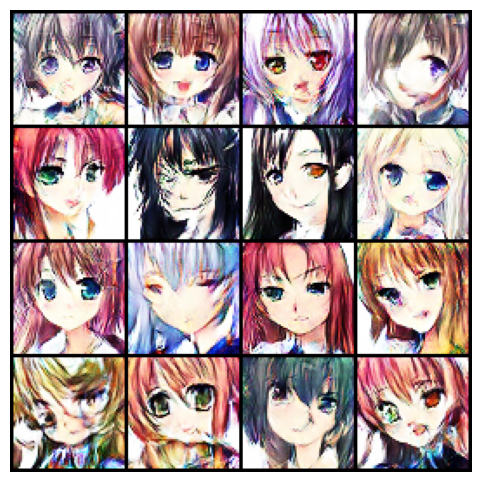

In [16]:
noise = torch.randn(16,Z_DIM,1,1).to(device)

fake = gen(noise).detach().cpu()

grid = make_grid(fake,nrow=4,normalize=True)

plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid,(1,2,0)))
plt.axis("off")
plt.show()

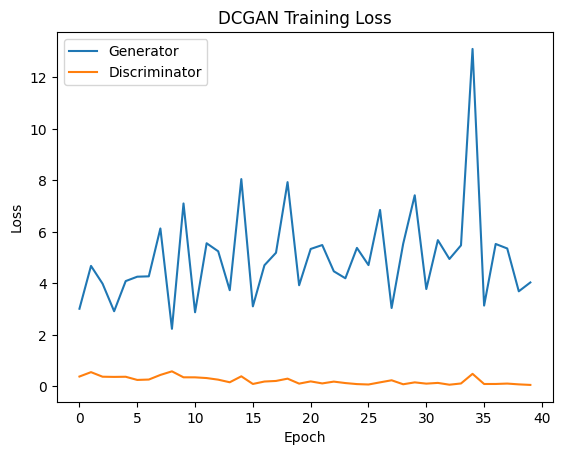

In [17]:
plt.plot(gen_losses,label="Generator")
plt.plot(disc_losses,label="Discriminator")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Loss")
plt.show()

In [22]:
class Critic(nn.Module):
    def __init__(self,channels_img,features_d):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(channels_img,features_d,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d,features_d*2,4,2,1),
            nn.InstanceNorm2d(features_d*2),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d*2,features_d*4,4,2,1),
            nn.InstanceNorm2d(features_d*4),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d*4,features_d*8,4,2,1),
            nn.InstanceNorm2d(features_d*8),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d*8,1,4,1,0)
        )

    def forward(self,x):
        return self.net(x).view(-1)

In [23]:
def gradient_penalty(critic,real,fake):

    batch_size,C,H,W = real.shape

    epsilon = torch.rand((batch_size,1,1,1)).repeat(1,C,H,W).to(device)

    interpolated = real*epsilon + fake*(1-epsilon)

    mixed_scores = critic(interpolated)

    gradient = torch.autograd.grad(
        inputs=interpolated,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True
    )[0]

    gradient = gradient.view(gradient.shape[0],-1)

    gradient_norm = gradient.norm(2,dim=1)

    gp = torch.mean((gradient_norm-1)**2)

    return gp

In [25]:
critic = Critic(CHANNELS_IMG,FEATURES_DISC).to(device)

opt_critic = optim.Adam(critic.parameters(),lr=LR,betas=BETAS)
opt_gen = optim.Adam(gen.parameters(),lr=LR,betas=BETAS)

In [26]:
critic_losses_wgan = []
gen_losses_wgan = []

for epoch in range(EPOCHS_WGAN):

    for real,_ in tqdm(loader):

        real = real.to(device)
        batch_size = real.shape[0]

        for _ in range(CRITIC_ITERATIONS):

            noise = torch.randn(batch_size,Z_DIM,1,1).to(device)

            fake = gen(noise)

            critic_real = critic(real).reshape(-1)
            critic_fake = critic(fake).reshape(-1)

            gp = gradient_penalty(critic,real,fake)

            loss_critic = -(torch.mean(critic_real) - torch.mean(critic_fake)) + LAMBDA_GP*gp

            critic.zero_grad()
            loss_critic.backward(retain_graph=True)
            opt_critic.step()

        output = critic(fake).reshape(-1)

        loss_gen = -torch.mean(output)

        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

    critic_losses_wgan.append(loss_critic.item())
    gen_losses_wgan.append(loss_gen.item())

    print(f"Epoch [{epoch}] Critic Loss: {loss_critic:.4f} Gen Loss: {loss_gen:.4f}")


100%|██████████| 337/337 [05:01<00:00,  1.12it/s]


Epoch [0] Critic Loss: -4.5675 Gen Loss: 1.0530


100%|██████████| 337/337 [05:00<00:00,  1.12it/s]


Epoch [1] Critic Loss: -4.8005 Gen Loss: 10.4047


100%|██████████| 337/337 [05:00<00:00,  1.12it/s]


...

Epoch [32] Critic Loss: -2.4175 Gen Loss: 2.9640


100%|██████████| 337/337 [05:00<00:00,  1.12it/s]


Epoch [33] Critic Loss: -2.6228 Gen Loss: 28.0911


100%|██████████| 337/337 [05:00<00:00,  1.12it/s]

Epoch [34] Critic Loss: -2.7347 Gen Loss: -1.3980


In [27]:
 torch.save(gen.state_dict(),"wgan_generator.pth")
 torch.save(critic.state_dict(),"wgan_critic.pth")

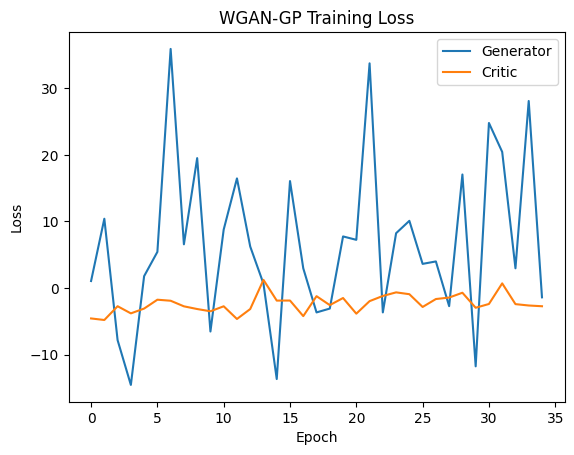

In [28]:
plt.plot(gen_losses_wgan,label="Generator")
plt.plot(critic_losses_wgan,label="Critic")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("WGAN-GP Training Loss")

plt.legend()
plt.show()

Text(0.5, 1.0, 'WGAN-GP Generated Images')

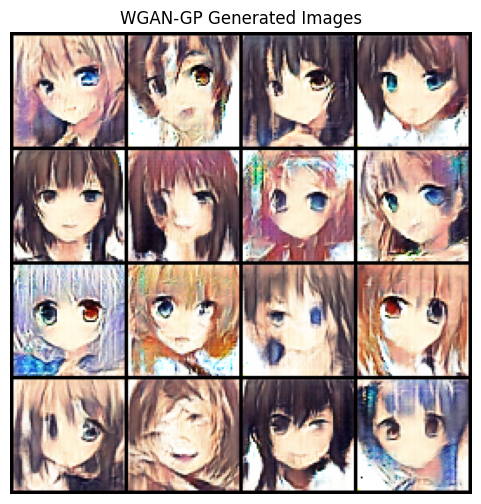

In [29]:
noise = torch.randn(16,Z_DIM,1,1).to(device)

fake = gen(noise).detach().cpu()

grid = make_grid(fake,nrow=4,normalize=True)

plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid,(1,2,0)))
plt.axis("off")
plt.title("WGAN-GP Generated Images")

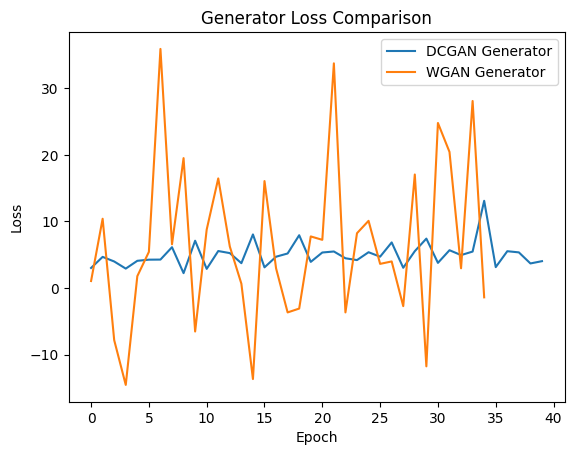

In [30]:
plt.plot(gen_losses,label="DCGAN Generator")
plt.plot(gen_losses_wgan,label="WGAN Generator")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Generator Loss Comparison")

plt.legend()
plt.show()

In [33]:
dcgan_gen = Generator(Z_DIM,CHANNELS_IMG,FEATURES_GEN).to(device)
dcgan_gen.load_state_dict(torch.load("generator.pth"))
dcgan_gen.eval()

wgan_gen = Generator(Z_DIM,CHANNELS_IMG,FEATURES_GEN).to(device)
wgan_gen.load_state_dict(torch.load("wgan_generator.pth"))
wgan_gen.eval()

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
 

In [ ]:
import gradio as gr

def generate_image(model):

    noise = torch.randn(1, Z_DIM, 1, 1).to(device)

    if model == "DCGAN":
        fake = dcgan_gen(noise)
    else:
        fake = wgan_gen(noise)

    # Convert tensor → numpy image
    img = fake.detach().cpu().squeeze(0)      # remove batch
    img = img.permute(1, 2, 0).numpy()        # CHW → HWC

    img = (img + 1) / 2                       # [-1,1] → [0,1]
    img = np.clip(img, 0, 1)

    return img

interface = gr.Interface(
    fn=generate_image,
    inputs=gr.Radio(["DCGAN","WGAN-GP"], label="Select Model"),
    outputs=gr.Image(type="numpy"),
    title="GAN Image Generator Comparison"
)

interface.launch(share=True)

#  Question 3: Domain Adaptation and Unpaired Image-to-Image Translation using CycleGAN 

In [2]:
import os
import random
import itertools
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.utils import make_grid, save_image
from PIL import Image

from torch.cuda.amp import autocast, GradScaler

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import gradio as gr

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

DATASET_PATH = "/kaggle/input/datasets/robinrausch/sketch2image-dataset-without-usecase/dataset-mixed/dataset-mixed"

BATCH_SIZE = 8
IMAGE_SIZE = 256
EPOCHS = 45
LR = 0.0002

LAMBDA_CYCLE = 10
LAMBDA_IDENTITY = 5

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
SAMPLE_DIR = "/kaggle/working/samples"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(SAMPLE_DIR, exist_ok=True)

cuda


In [5]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [6]:
class SketchPhotoDataset(Dataset):
    def __init__(self, root_dir, transform=None):

        self.root = root_dir
        self.transform = transform
        files = os.listdir(root_dir)

        originals = [f for f in files if "_original" in f]

        self.pairs = []

        for orig in originals:

            base = orig.split("_original")[0]

            drawn_jpg = base + "_drawn.jpg"
            drawn_png = base + "_drawn.png"

            if drawn_jpg in files:
                self.pairs.append((orig, drawn_jpg))

            elif drawn_png in files:
                self.pairs.append((orig, drawn_png))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):

        orig_name, drawn_name = self.pairs[index]

        photo = Image.open(os.path.join(self.root, orig_name)).convert("RGB")
        sketch = Image.open(os.path.join(self.root, drawn_name)).convert("RGB")

        if self.transform:
            photo = self.transform(photo)
            sketch = self.transform(sketch)

        return sketch, photo

In [7]:
dataset = SketchPhotoDataset(DATASET_PATH, transform)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

print("Dataset size:", len(dataset))

Dataset size: 801


In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3,1,1),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels,3,1,1),
            nn.InstanceNorm2d(channels)
        )

    def forward(self,x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self, channels=3):

        super().__init__()

        model = [
            nn.Conv2d(channels,64,7,1,3),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        ]

        model += [
            nn.Conv2d(64,128,3,2,1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True)
        ]

        model += [
            nn.Conv2d(128,256,3,2,1),
            nn.InstanceNorm2d(256),
            nn.ReLU(inplace=True)
        ]

        for _ in range(6):
            model += [ResidualBlock(256)]

        model += [
            nn.ConvTranspose2d(256,128,3,2,1,output_padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True)
        ]

        model += [
            nn.ConvTranspose2d(128,64,3,2,1,output_padding=1),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        ]

        model += [
            nn.Conv2d(64,3,7,1,3),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*model)

    def forward(self,x):
        return self.model(x)

In [9]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        def block(in_c,out_c,normalize=True):

            layers=[nn.Conv2d(in_c,out_c,4,2,1)]

            if normalize:
                layers.append(nn.InstanceNorm2d(out_c))

            layers.append(nn.LeakyReLU(0.2))

            return layers

        self.model = nn.Sequential(

            *block(3,64,False),
            *block(64,128),
            *block(128,256),
            *block(256,512),
            nn.Conv2d(512,1,4,1,1)

        )

    def forward(self,x):
        return self.model(x)

In [10]:
G_sketch2photo = Generator().to(DEVICE)
G_photo2sketch = Generator().to(DEVICE)

D_photo = Discriminator().to(DEVICE)
D_sketch = Discriminator().to(DEVICE)

In [11]:
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

In [13]:
opt_G = optim.Adam(
    itertools.chain(
        G_sketch2photo.parameters(),
        G_photo2sketch.parameters()
    ),
    lr=LR,
    betas=(0.5,0.999)
)

opt_D_photo = optim.Adam(D_photo.parameters(),lr=LR,betas=(0.5,0.999))
opt_D_sketch = optim.Adam(D_sketch.parameters(),lr=LR,betas=(0.5,0.999))

In [14]:
gen_losses = []
disc_losses = []
cycle_losses = []

for epoch in range(EPOCHS):

    epoch_gen = 0
    epoch_disc = 0
    epoch_cycle = 0

    for i,(sketch,photo) in enumerate(dataloader):

        sketch = sketch.to(DEVICE)
        photo = photo.to(DEVICE)

         # create labels dynamically
        pred = D_photo(photo)
        valid = torch.ones_like(pred)
        fake = torch.zeros_like(pred)

       
        # -------------------
        # Train Generators
        # -------------------

        fake_photo = G_sketch2photo(sketch)
        loss_GAN_s2p = criterion_GAN(D_photo(fake_photo),valid)

        fake_sketch = G_photo2sketch(photo)
        loss_GAN_p2s = criterion_GAN(D_sketch(fake_sketch),valid)

        rec_sketch = G_photo2sketch(fake_photo)
        loss_cycle_A = criterion_cycle(rec_sketch,sketch)

        rec_photo = G_sketch2photo(fake_sketch)
        loss_cycle_B = criterion_cycle(rec_photo,photo)

        id_photo = G_sketch2photo(photo)
        loss_id_photo = criterion_identity(id_photo, photo)

        id_sketch = G_photo2sketch(sketch)
        loss_id_sketch = criterion_identity(id_sketch, sketch)

        loss_cycle = loss_cycle_A + loss_cycle_B

        loss_G = (
            loss_GAN_s2p +
            loss_GAN_p2s +
            LAMBDA_CYCLE * loss_cycle +
            LAMBDA_IDENTITY * (loss_id_photo + loss_id_sketch)
        )

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        # -------------------
        # Train Discriminator Photo
        # -------------------

        loss_real = criterion_GAN(D_photo(photo),valid)
        loss_fake = criterion_GAN(D_photo(fake_photo.detach()),fake)

        loss_D_photo = (loss_real + loss_fake)/2

        opt_D_photo.zero_grad()
        loss_D_photo.backward()
        opt_D_photo.step()

        # -------------------
        # Train Discriminator Sketch
        # -------------------

        loss_real = criterion_GAN(D_sketch(sketch),valid)
        loss_fake = criterion_GAN(D_sketch(fake_sketch.detach()),fake)

        loss_D_sketch = (loss_real + loss_fake)/2

        opt_D_sketch.zero_grad()
        loss_D_sketch.backward()
        opt_D_sketch.step()

        epoch_gen += loss_G.item()
        epoch_disc += (loss_D_photo + loss_D_sketch).item()
        epoch_cycle += loss_cycle.item()

    gen_losses.append(epoch_gen / len(dataloader))
    disc_losses.append(epoch_disc / len(dataloader))
    cycle_losses.append(epoch_cycle / len(dataloader))

    print(f"Epoch {epoch}/{EPOCHS}")
    print("Generator Loss:", gen_losses[-1])
    print("Discriminator Loss:", disc_losses[-1])
    print("Cycle Loss:", cycle_losses[-1])

Epoch 0/45
Generator Loss: 7.449684709605604
Discriminator Loss: 0.5046634532437466
Cycle Loss: 0.4399961318710063
Epoch 1/45
Generator Loss: 5.634379377459536
Discriminator Loss: 0.4234686060117023
Cycle Loss: 0.33106886381560036
Epoch 2/45
Generator Loss: 4.909634122754087
Discriminator Loss: 0.438363259381587
Cycle Loss: 0.28059080302125156
Epoch 3/45
Generator Loss: 4.566557886576889
Discriminator Loss: 0.4029905704578551
Cycle Loss: 0.26179295925810786
Epoch 4/45
Generator Loss: 4.685268123551171
Discriminator Loss: 0.4096636944773174
Cycle Loss: 0.27077417429721
Epoch 5/45
Generator Loss: 4.76958429459298
Discriminator Loss: 0.3829232908711575
Cycle Loss: 0.2727041284341623
Epoch 6/45
Generator Loss: 4.235283256757377
Discriminator Loss: 0.3929587112795008
Cycle Loss: 0.23603862110931095
Epoch 7/45
Generator Loss: 4.547786483670225
Discriminator Loss: 0.36962203710976216
Cycle Loss: 0.25263980045767115
Epoch 8/45
Generator Loss: 4.073933405451255
Discriminator Loss: 0.42593736872

In [17]:
save_image(fake_photo[:5], f"{SAMPLE_DIR}/epoch_{epoch}.png", normalize=True)

In [19]:
torch.save(G_sketch2photo.state_dict(), f"{CHECKPOINT_DIR}/G_s2p.pth")
torch.save(G_photo2sketch.state_dict(), f"{CHECKPOINT_DIR}/G_p2s.pth")

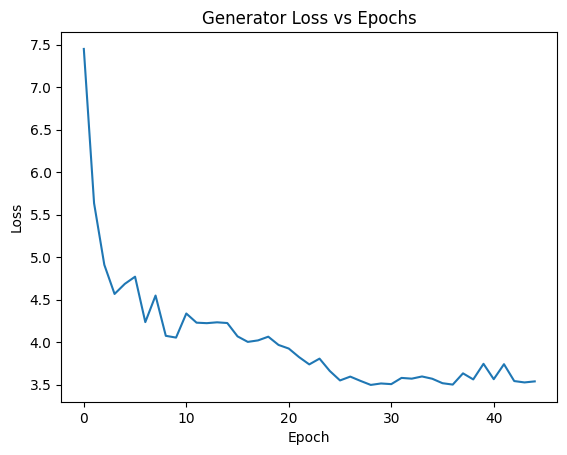

In [20]:
plt.figure()
plt.plot(gen_losses)
plt.title("Generator Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

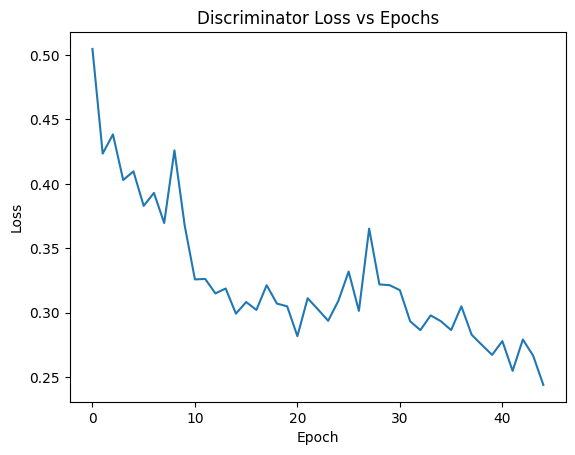

In [21]:
plt.figure()
plt.plot(disc_losses)
plt.title("Discriminator Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

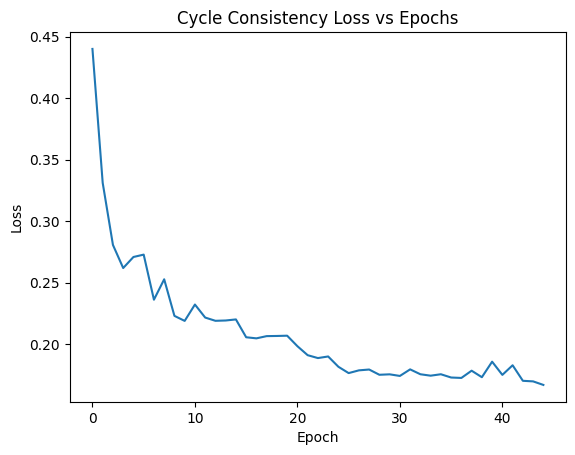

In [22]:
plt.figure()
plt.plot(cycle_losses)
plt.title("Cycle Consistency Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [25]:
def tensor_to_image(tensor):

    img = tensor.detach().cpu().numpy()
    img = np.transpose(img,(1,2,0))
    img = (img + 1)/2

    return img

In [26]:
ssim_scores = []
psnr_scores = []

G_sketch2photo.eval()

for sketch, photo in dataloader:

    sketch = sketch.to(DEVICE)
    photo = photo.to(DEVICE)

    with torch.no_grad():
        fake = G_sketch2photo(sketch)

    for i in range(sketch.size(0)):

        real = tensor_to_image(photo[i])
        gen = tensor_to_image(fake[i])

        ssim_score = ssim(real, gen, channel_axis=2, data_range=1.0)
        psnr_score = psnr(real, gen, data_range=1.0)

        ssim_scores.append(ssim_score)
        psnr_scores.append(psnr_score)

print("Average SSIM:", np.mean(ssim_scores))
print("Average PSNR:", np.mean(psnr_scores))

Average SSIM: 0.1513317
Average PSNR: 8.528516902246498


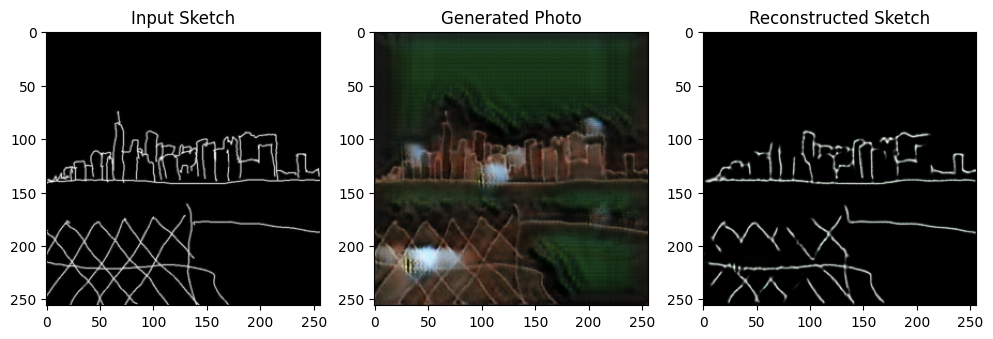

In [27]:
sketch,photo = next(iter(dataloader))

sketch = sketch.to(DEVICE)
photo = photo.to(DEVICE)

with torch.no_grad():

    fake_photo = G_sketch2photo(sketch)
    reconstructed = G_photo2sketch(fake_photo)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Sketch")
plt.imshow(tensor_to_image(sketch[0]))

plt.subplot(1,3,2)
plt.title("Generated Photo")
plt.imshow(tensor_to_image(fake_photo[0]))

plt.subplot(1,3,3)
plt.title("Reconstructed Sketch")
plt.imshow(tensor_to_image(reconstructed[0]))

plt.show()

In [29]:
def translate_image(input_image):

    img = Image.fromarray(input_image).convert("RGB")
    img = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = G_sketch2photo(img)

    output = tensor_to_image(output[0])

    return output

In [30]:
import gradio as gr
demo = gr.Interface(
    fn=translate_image,
    inputs=gr.Image(),
    outputs=gr.Image(),
    title="Sketch to Photo Translation using CycleGAN",
    description="Upload a sketch image to generate a photo"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://30a23c387bee59f656.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



# Question 2: Doodle-to-Real Image Translation andColorization using Pix2Pix


In [1]:
!pip install torch torchvision torchaudio
!pip install opencv-python matplotlib scikit-image gradio

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
class Pix2PixDataset(Dataset):

    def __init__(self, input_dir, target_dir, transform=None):

        self.input_paths = sorted(os.listdir(input_dir))
        self.target_paths = sorted(os.listdir(target_dir))

        self.input_dir = input_dir
        self.target_dir = target_dir
        self.transform = transform

        self.length = min(len(self.input_paths), len(self.target_paths))

        print("Total pairs:", self.length)

    def __len__(self):
        return self.length

    def __getitem__(self, index):

        input_img = Image.open(
            os.path.join(self.input_dir, self.input_paths[index])
        ).convert("RGB")

        target_img = Image.open(
            os.path.join(self.target_dir, self.target_paths[index])
        ).convert("RGB")

        if self.transform:
            input_img = self.transform(input_img)
            target_img = self.transform(target_img)

        return input_img, target_img

In [9]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [11]:
dataset = Pix2PixDataset(
    "/kaggle/input/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/sketches",
    "/kaggle/input/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/photos",
    transform
)

loader = DataLoader(dataset, batch_size=16, shuffle=True)

Total pairs: 188


In [14]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        def down(in_c,out_c,norm=True):
            layers=[nn.Conv2d(in_c,out_c,4,2,1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2))
            return nn.Sequential(*layers)

        def up(in_c,out_c):
            return nn.Sequential(
                nn.ConvTranspose2d(in_c,out_c,4,2,1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            )

        self.d1=down(3,64,False)
        self.d2=down(64,128)
        self.d3=down(128,256)
        self.d4=down(256,512)

        self.u1=up(512,256)
        self.u2=up(512,128)
        self.u3=up(256,64)

        self.final=nn.Sequential(
            nn.ConvTranspose2d(128,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):

        d1=self.d1(x)
        d2=self.d2(d1)
        d3=self.d3(d2)
        d4=self.d4(d3)

        u1=self.u1(d4)
        u1=torch.cat([u1,d3],1)

        u2=self.u2(u1)
        u2=torch.cat([u2,d2],1)

        u3=self.u3(u2)
        u3=torch.cat([u3,d1],1)

        return self.final(u3)

In [18]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model=nn.Sequential(

            nn.Conv2d(6,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,1,4,1,1)
        )

    def forward(self,x,y):
        inp=torch.cat([x,y],1)
        return self.model(inp)

In [20]:
criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()

lambda_L1 = 100

In [21]:
gen = Generator().to(device)
disc = Discriminator().to(device)

opt_gen = torch.optim.Adam(gen.parameters(),lr=0.0002,betas=(0.5,0.999))
opt_disc = torch.optim.Adam(disc.parameters(),lr=0.0002,betas=(0.5,0.999))

In [22]:
G_losses=[]
D_losses=[]

epochs=100

for epoch in range(epochs):

    for x,y in loader:

        x=x.to(device)
        y=y.to(device)

        fake=gen(x)

        # Train Discriminator
        D_real=disc(x,y)
        D_fake=disc(x,fake.detach())

        loss_real=criterion_GAN(D_real,torch.ones_like(D_real))
        loss_fake=criterion_GAN(D_fake,torch.zeros_like(D_fake))

        D_loss=(loss_real+loss_fake)/2

        opt_disc.zero_grad()
        D_loss.backward()
        opt_disc.step()

        # Train Generator
        D_fake=disc(x,fake)

        G_adv=criterion_GAN(D_fake,torch.ones_like(D_fake))
        G_L1=criterion_L1(fake,y)*lambda_L1

        G_loss=G_adv+G_L1

        opt_gen.zero_grad()
        G_loss.backward()
        opt_gen.step()

    G_losses.append(G_loss.item())
    D_losses.append(D_loss.item())

    print(f"Epoch {epoch} G_loss:{G_loss.item()} D_loss:{D_loss.item()}")

Epoch 0 G_loss:33.07124328613281 D_loss:0.5655466318130493
Epoch 1 G_loss:30.641454696655273 D_loss:0.4363386929035187
Epoch 2 G_loss:31.198368072509766 D_loss:0.7135876417160034
Epoch 3 G_loss:25.174728393554688 D_loss:0.45933035016059875
Epoch 4 G_loss:23.178373336791992 D_loss:0.7073473930358887
Epoch 5 G_loss:29.550073623657227 D_loss:0.42047539353370667
Epoch 6 G_loss:26.008224487304688 D_loss:0.25405368208885193
Epoch 7 G_loss:25.958200454711914 D_loss:0.20644254982471466
Epoch 8 G_loss:24.046411514282227 D_loss:0.240968257188797
Epoch 9 G_loss:25.40468978881836 D_loss:0.36610931158065796
Epoch 10 G_loss:28.74091911315918 D_loss:0.22477272152900696
Epoch 11 G_loss:35.8690185546875 D_loss:0.3246561586856842
Epoch 12 G_loss:23.325716018676758 D_loss:0.20549626648426056
Epoch 13 G_loss:28.980709075927734 D_loss:0.16271069645881653
Epoch 14 G_loss:24.703115463256836 D_loss:0.5723738074302673
Epoch 15 G_loss:25.114212036132812 D_loss:0.3689825236797333
Epoch 16 G_loss:24.1403217315673

In [25]:
torch.save(gen.state_dict(), "pix2pix_generator.pth")

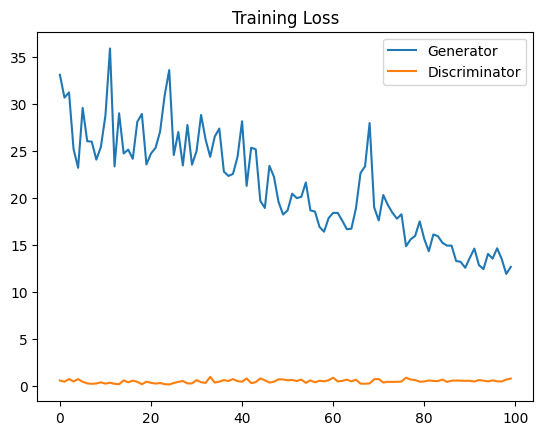

In [26]:
plt.plot(G_losses,label="Generator")
plt.plot(D_losses,label="Discriminator")
plt.legend()
plt.title("Training Loss")
plt.show()

In [28]:
def show_images(x,fake,y):

    x=x[0].permute(1,2,0).cpu().detach()*0.5+0.5
    fake=fake[0].permute(1,2,0).cpu().detach()*0.5+0.5
    y=y[0].permute(1,2,0).cpu().detach()*0.5+0.5

    fig,ax=plt.subplots(1,3,figsize=(12,4))

    ax[0].imshow(x)
    ax[0].set_title("Sketch")

    ax[1].imshow(fake)
    ax[1].set_title("Generated")

    ax[2].imshow(y)
    ax[2].set_title("Real")

    plt.show()

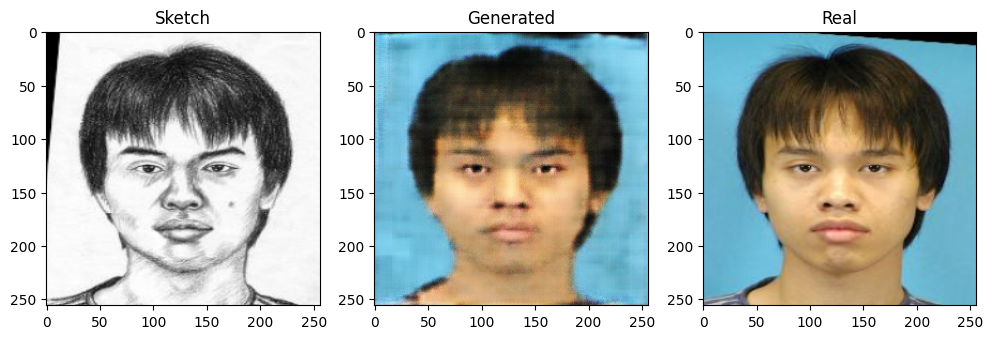

In [29]:
x,y=next(iter(loader))
x=x.to(device)
y=y.to(device)

fake=gen(x)

show_images(x,fake,y)

In [33]:
fake_img = fake[0].permute(1,2,0).cpu().detach().numpy()
real_img = y[0].permute(1,2,0).cpu().detach().numpy()

# Convert from [-1,1] → [0,1]
fake_img = (fake_img * 0.5) + 0.5
real_img = (real_img * 0.5) + 0.5

ssim_score = ssim(real_img, fake_img, channel_axis=2, data_range=1.0)
psnr_score = psnr(real_img, fake_img, data_range=1.0)

print("SSIM:", ssim_score)
print("PSNR:", psnr_score)

SSIM: 0.6412835
PSNR: 21.126055313727274


In [35]:
def generate(image):

    # 🔴 Gradio gives numpy → convert to PIL
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image.astype('uint8'))

    img = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        fake = gen(img)

    fake = fake.squeeze().permute(1,2,0).cpu().numpy()

    # convert back to [0,1]
    fake = (fake * 0.5) + 0.5

    return fake

In [36]:
import gradio as gr
demo = gr.Interface(
    fn=generate,
    inputs=gr.Image(type="pil"),
    outputs="image"
)
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://eb022a18ec227cfa53.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
